<a href="https://colab.research.google.com/github/VSUrhuel/forage-classifications/blob/main/Howard_MobilenetV3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [36]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from torch.utils.mobile_optimizer import optimize_for_mobile
from tqdm import tqdm
import os
import time
from google.colab import drive

In [37]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [38]:
BASE_DIR = '/content/drive/MyDrive/Undergrad Thesis/Dataset'
TRAIN_DIR = os.path.join(BASE_DIR, 'train')
VAL_DIR = os.path.join(BASE_DIR, 'val')
SAVE_PATH = '/content/drive/MyDrive/Undergrad Thesis/Dataset/Models'
NUM_CLASSES = 14
BATCH_SIZE = 32
NUM_EPOCHS = 50
UNFREEZE_EPOCHS = 7
LEARNING_RATE_HEAD = 3e-3
LEARNING_RATE_FINE = 3e-5
IMAGE_SIZE = 224
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

In [39]:
from re import I
# Use RandomResizedCrop to prevent distorting leaf shapes
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((256)),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [40]:
train_dataset = datasets.ImageFolder(
    root=TRAIN_DIR,
    transform=train_transforms
)

val_dataset = datasets.ImageFolder(
    root=VAL_DIR,
    transform=val_transforms
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

print(f"✅ Loaded {len(train_dataset)} training images and {len(val_dataset)} validation images.")
print(f"   Classes: {train_dataset.classes}")

✅ Loaded 3577 training images and 763 validation images.
   Classes: ['Carabao Grass', 'Centro', 'Desmodium', 'Fleminga', 'Gliricidia', 'Guinea', 'Indigofera', 'Kudzu', 'Leucaena', 'Molato', 'Mombasa', 'Napier Grass', 'Para Grass', 'Setaria']


In [41]:
def get_model(num_classes, freeze_backbone=True):
  model = models.mobilenet_v3_small(weights='IMAGENET1K_V1')

  if freeze_backbone:
    for param in model.parameters():
      param.requires_grad = False

  # Replace the Classifier Head
  # MobileNetV3 Small classifier: Linear -> HardSwish -> Dropout -> Linear
  in_features = model.classifier[3].in_features
  model.classifier[3] = nn.Linear(in_features, num_classes)

  return model

model = get_model(NUM_CLASSES, freeze_backbone=True)
model = model.to(DEVICE)

In [42]:
class EarlyStopping:
    def __init__(self, patience=5, delta=0):
        self.patience = patience
        self.delta = delta
        self.best_score = None
        self.early_stop = False
        self.counter = 0
        self.best_model_state = None

    def __call__(self, val_loss, model):
        score = -val_loss

        if self.best_score is None:
            self.best_score = score
            self.best_model_state = model.state_dict()
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.best_model_state = model.state_dict()
            self.counter = 0

    def load_best_model(self, model):
        model.load_state_dict(self.best_model_state)

In [43]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=LEARNING_RATE_HEAD)
early_stopping = EarlyStopping(patience=5, delta=0.01)

In [44]:
def train_one_epoch(model, loader, optimizer):
  model.train()
  running_loss, correct, total = 0.0, 0, 0

  loop = tqdm(loader, desc="Training", leave=False)
  for images, labels in loop:
    images, labels = images.to(DEVICE), labels.to(DEVICE)

    optimizer.zero_grad()
    outputs = model(images)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()

    running_loss += loss.item()
    _, preds = torch.max(outputs, 1)
    total += labels.size(0)
    correct += (preds == labels).sum().item()

    loop.set_postfix(loss=loss.item())

  acc = correct / total * 100
  return running_loss / len(loader), acc

In [45]:
def validate(model, loader):
  model.eval()
  running_loss, correct, total = 0.0, 0, 0

  with torch.no_grad():
    for images, labels in tqdm(loader, desc="Validation", leave=False):
      images, labels = images.to(DEVICE), labels.to(DEVICE)
      outputs = model(images)
      loss = criterion(outputs, labels)

      running_loss += loss.item()
      _, preds = torch.max(outputs, 1)
      total += labels.size(0)
      correct += (preds == labels).sum().item()

  acc = correct / total * 100
  return running_loss / len(loader), acc


In [46]:
best_val_acc = 0.0
start_time = time.time()

for epoch in range(NUM_EPOCHS):
  print(f"\n--- Epoch [{epoch+1}/{NUM_EPOCHS}] ---")

  if epoch == UNFREEZE_EPOCHS:
    print("🔓 Unfreezing backbone... Switching to fine-tuning mode.")
    for param in model.parameters():
      param.requires_grad = True

    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE_FINE)

  train_loss, train_acc = train_one_epoch(model, train_loader, optimizer)
  val_loss, val_acc = validate(model, val_loader)

  print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
  print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

  if val_acc > best_val_acc:
    best_val_acc = val_acc
    torch.save(model.state_dict(), os.path.join(SAVE_PATH, 'best_model.pth'))
    print(f"Best model saved! ({val_acc:.2f}%)")

  early_stopping(val_loss, model)
  if early_stopping.early_stop:
      print("Early stopping")
      break

print(f"\n Training Complete. Best Val Accuracy: {best_val_acc:.2f}%")


--- Epoch [1/50] ---


Train Loss: 1.4420 | Train Acc: 65.56%
Val Loss: 1.2456 | Val Acc: 72.08%
Best model saved! (72.08%)

--- Epoch [2/50] ---


Train Loss: 1.1620 | Train Acc: 76.99%
Val Loss: 1.0670 | Val Acc: 81.39%
Best model saved! (81.39%)

--- Epoch [3/50] ---


Train Loss: 1.1169 | Train Acc: 79.79%
Val Loss: 1.0370 | Val Acc: 83.75%
Best model saved! (83.75%)

--- Epoch [4/50] ---


Train Loss: 1.0873 | Train Acc: 80.88%
Val Loss: 1.0420 | Val Acc: 83.62%

--- Epoch [5/50] ---


...

Train Loss: 0.7327 | Train Acc: 97.32%
Val Loss: 0.8049 | Val Acc: 93.45%
Best model saved! (93.45%)

--- Epoch [33/50] ---


Train Loss: 0.7303 | Train Acc: 97.18%
Val Loss: 0.8046 | Val Acc: 93.05%

--- Epoch [34/50] ---


Train Loss: 0.7208 | Train Acc: 97.57%
Val Loss: 0.8035 | Val Acc: 93.32%

--- Epoch [35/50] ---


Train Loss: 0.7120 | Train Acc: 97.71%
Val Loss: 0.8010 | Val Acc: 93.32%

--- Epoch [36/50] ---


Train Loss: 0.7164 | Train Acc: 97.29%
Val Loss: 0.7998 | Val Acc: 93.05%
Early stopping

 Training Complete. Best Val Accuracy: 93.45%


🚀 Starting Inference on 763 images...

⚡ INFERENCE PERFORMANCE
Average Inference Time: 0.27 ms/image
Throughput:             3639.58 FPS

📈 CLASSIFICATION REPORT
Overall Accuracy: 93.45%
------------------------------------------------------------
               precision    recall  f1-score   support

Carabao Grass     1.0000    1.0000    1.0000        55
       Centro     0.9565    0.8800    0.9167        50
    Desmodium     1.0000    0.9828    0.9913        58
     Fleminga     0.8814    0.9630    0.9204        54
   Gliricidia     0.9492    0.9825    0.9655        57
       Guinea     0.8226    0.8793    0.8500        58
   Indigofera     0.9623    1.0000    0.9808        51
        Kudzu     0.9783    0.8824    0.9278        51
     Leucaena     1.0000    0.9815    0.9907        54
       Molato     0.8727    0.8421    0.8571        57
      Mombasa     0.9231    0.8276    0.8727        58
 Napier Grass     0.9000    0.9000    0.9000        50
   Para Grass     0.9630    0.9811  

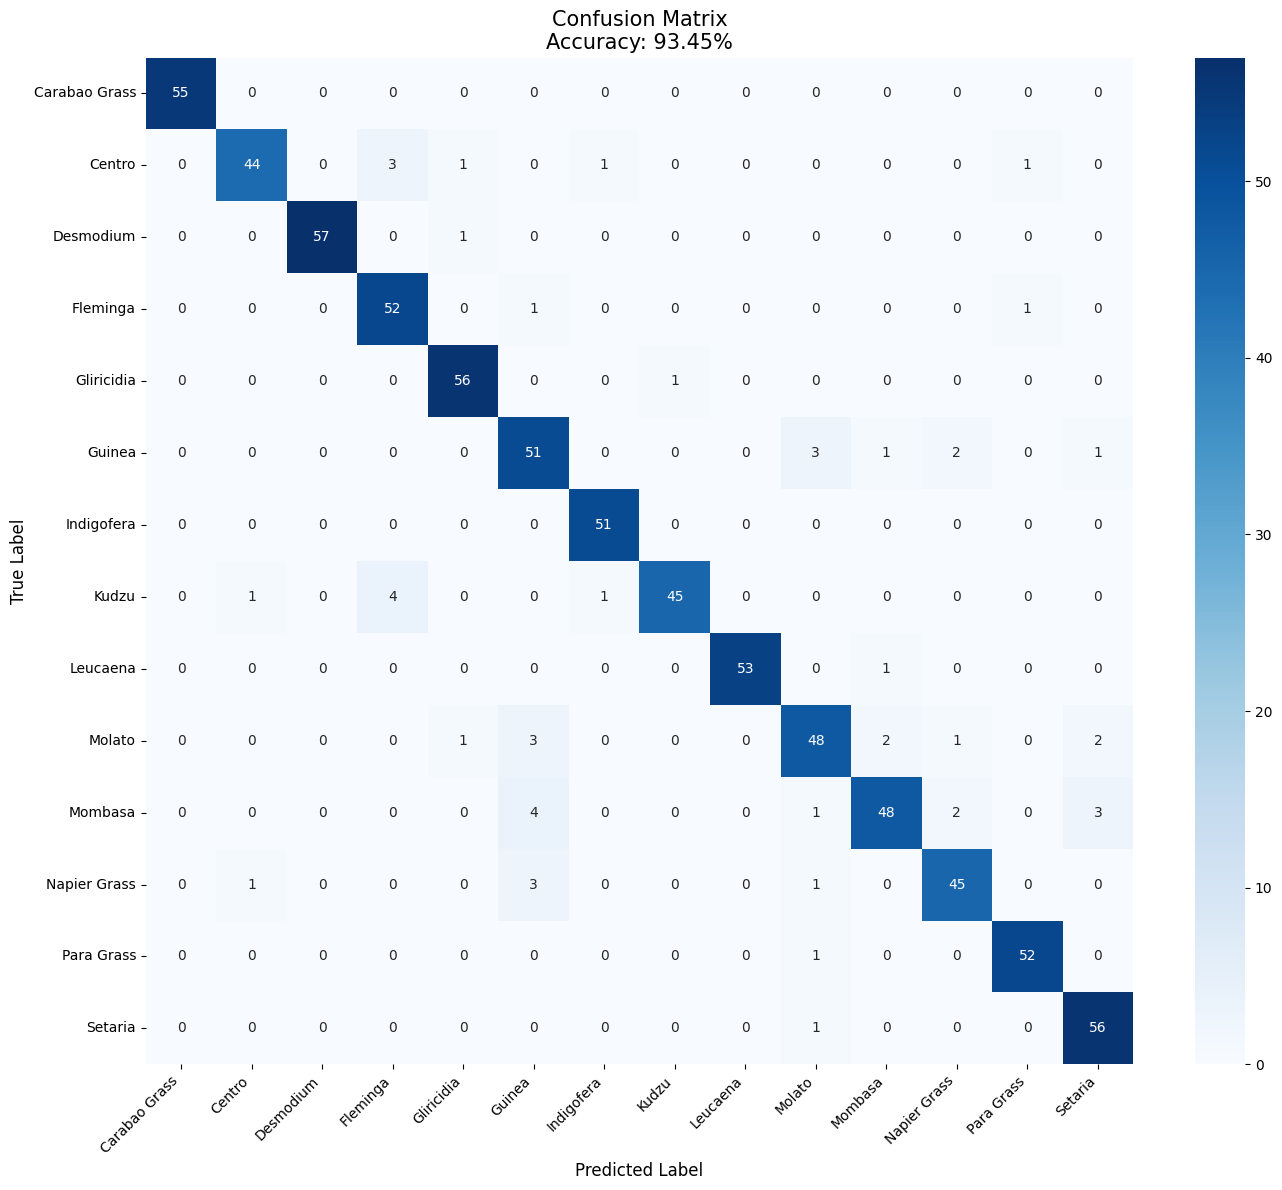

In [52]:
import torch
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import numpy as np
import time

MODEL_PATH = "/content/drive/MyDrive/Undergrad Thesis/Dataset/Models/best_model.pth"
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.to(DEVICE)
model.eval()

all_preds = []
all_labels = []
inference_times = [] # Store time taken for each batch

print(f"🚀 Starting Inference on {len(val_loader.dataset)} images...")

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        if DEVICE == 'cuda': torch.cuda.synchronize()
        start_time = time.time()

        outputs = model(images)

        if DEVICE == 'cuda': torch.cuda.synchronize()
        end_time = time.time()
        # -------------------------------------------------

        # Calculate time per image in this batch
        batch_time = end_time - start_time
        inference_times.append(batch_time / len(images))

        # Get Predictions
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

avg_time_per_img = np.mean(inference_times) * 1000 # Convert to ms
fps = 1 / np.mean(inference_times)

print("\n" + "="*30)
print("⚡ INFERENCE PERFORMANCE")
print("="*30)
print(f"Average Inference Time: {avg_time_per_img:.2f} ms/image")
print(f"Throughput:             {fps:.2f} FPS")

# B. Classification Metrics
class_names = val_dataset.classes
overall_acc = accuracy_score(all_labels, all_preds)

print("\n" + "="*30)
print("📈 CLASSIFICATION REPORT")
print("="*30)
print(f"Overall Accuracy: {overall_acc*100:.2f}%")
print("-" * 60)

# Generates a table with Precision, Recall, F1-Score for EACH class
report = classification_report(all_labels, all_preds, target_names=class_names, digits=4)
print(report)

# ==========================================
# 4. VISUALIZE CONFUSION MATRIX
# ==========================================
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(14, 12)) # Larger figure for 14 classes
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title(f'Confusion Matrix\nAccuracy: {overall_acc*100:.2f}%', fontsize=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()